> I worked on a customer churn prediction project where I analyzed customer behavior to identify factors causing churn and built a model to predict high-risk customers so the company can take preventive retention actions.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/telco-customer-churn/__results__.html
/kaggle/input/telco-customer-churn/__resultx__.html
/kaggle/input/telco-customer-churn/__notebook__.ipynb
/kaggle/input/telco-customer-churn/__output__.json
/kaggle/input/telco-customer-churn/churn_histogram.png
/kaggle/input/telco-customer-churn/custom.css
/kaggle/input/telco-customer-churn/__results___files/__results___38_1.png
/kaggle/input/telco-customer-churn/__results___files/__results___24_14.png
/kaggle/input/telco-customer-churn/__results___files/__results___24_3.png
/kaggle/input/telco-customer-churn/__results___files/__results___20_0.png
/kaggle/input/telco-customer-churn/__results___files/__results___24_5.png
/kaggle/input/telco-customer-churn/__results___files/__results___24_0.png
/kaggle/input/telco-customer-churn/__results___files/__results___24_7.png
/kaggle/input/telco-customer-churn/__results___files/__results___24_11.png
/kaggle/input/telco-customer-churn/__results___files/__results___24_9.png
/kaggle/input/telco-cu

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

Data Reading and Exploration

In [21]:
df = pd.read_csv("/kaggle/input/d/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [22]:
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [24]:
print(df.tail())

      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
7038          Yes               Yes             DSL            Yes  ...   
7039          Yes               Yes     Fiber optic             No  ...   
7040           No  No phone service             DSL            Yes  ...   
7041          Yes               Yes     Fiber optic             No  ...   
7042          Yes                No     Fiber optic            Yes  ...   

     DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
7038              Yes         Yes         Yes  

In [25]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [26]:
print(df.columns)


Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [27]:
print(df.isnull().sum())


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [28]:
print(df.duplicated().sum())


0


In [29]:
print(df.describe())


       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


In [30]:
print(df.describe(include = "O"))

        customerID gender Partner Dependents PhoneService MultipleLines  \
count         7043   7043    7043       7043         7043          7043   
unique        7043      2       2          2            2             3   
top     7590-VHVEG   Male      No         No          Yes            No   
freq             1   3555    3641       4933         6361          3390   

       InternetService OnlineSecurity OnlineBackup DeviceProtection  \
count             7043           7043         7043             7043   
unique               3              3            3                3   
top        Fiber optic             No           No               No   
freq              3096           3498         3088             3095   

       TechSupport StreamingTV StreamingMovies        Contract  \
count         7043        7043            7043            7043   
unique           3           3               3               3   
top             No          No              No  Month-to-month   
freq

In [31]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,0
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,0
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,1


   gender        Contract  Churn_rate
0  Female  Month-to-month    0.437403
1  Female        One year    0.104457
2  Female        Two year    0.026036
3    Male  Month-to-month    0.416923
4    Male        One year    0.120530
5    Male        Two year    0.030588


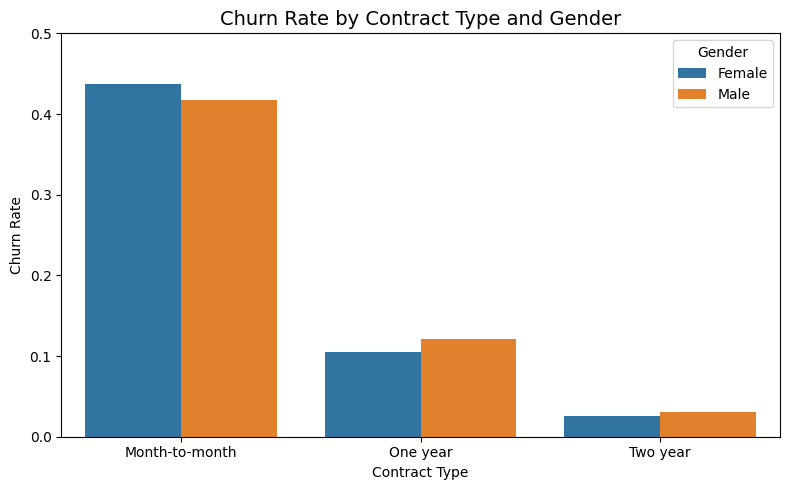

In [32]:
#Gender types VS Churn Rates
churn_rate = (df.groupby(["gender", "Contract"])["Churn"].mean().reset_index().rename(columns={"Churn":"Churn_rate"}))
print(churn_rate)
plt.figure(figsize=(8,5))
sns.barplot(
    data=churn_rate,
    x = "Contract",
    y = "Churn_rate",
    hue = "gender"
)
plt.title("Churn Rate by Contract Type and Gender", fontsize=14)
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate")
plt.ylim(0, 0.5)
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

  Partner Dependents  Churn_rate
0      No         No    0.342378
1      No        Yes    0.213296
2     Yes         No    0.254083
3     Yes        Yes    0.142367


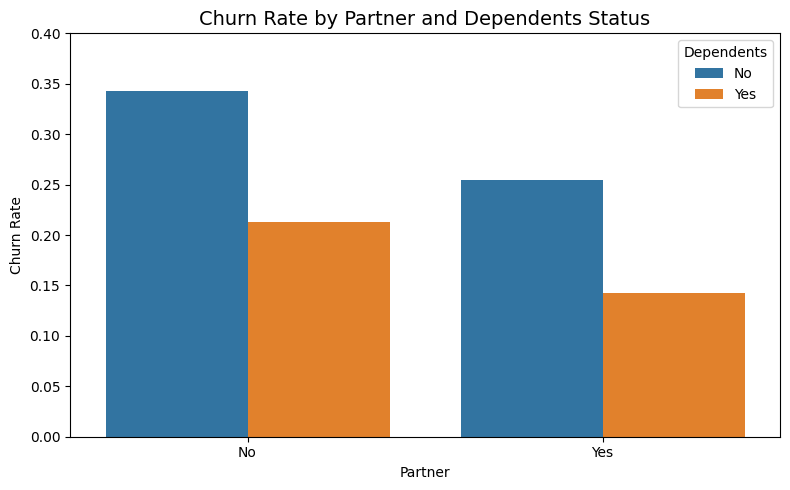

In [36]:
#Partner/Dependents VS Churn Rate
partner_churn = (df.groupby(["Partner","Dependents"])["Churn"].mean()
                .reset_index().rename(columns = {"Churn":"Churn_rate"}))
print(partner_churn)
plt.figure(figsize=(8,5))
sns.barplot(
    data=partner_churn,
    x="Partner",
    y="Churn_rate",
    hue="Dependents"
)
plt.title("Churn Rate by Partner and Dependents Status", fontsize=14)
plt.xlabel("Partner")
plt.ylabel("Churn Rate")
plt.ylim(0, 0.4)
plt.legend(title="Dependents")
plt.tight_layout()
plt.show()

/tmp/ipykernel_47/1392637542.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("tenure_group")["Churn"].mean().reset_index()
/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


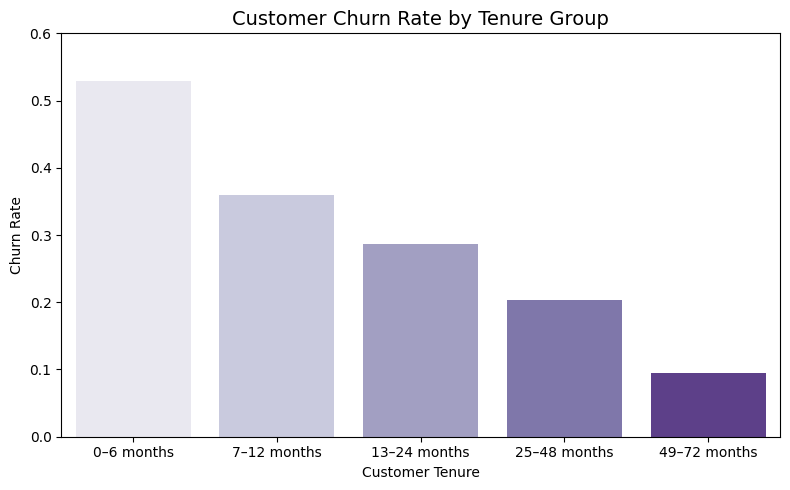

In [37]:
# Tenure VS Churn Rate
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins = [0,6,12,24,48,72],
    labels = [
        "0–6 months",
        "7–12 months",
        "13–24 months",
        "25–48 months",
        "49–72 months"
    ],
    include_lowest = True
)
tenure_churn = (
    df.groupby("tenure_group")["Churn"].mean().reset_index()
    .rename(columns={"Churn": "Churn_rate"})
)
plt.figure(figsize=(8,5))
sns.barplot(
    data=tenure_churn,
    x="tenure_group",
    y="Churn_rate",
    palette="Purples"
)
plt.title("Customer Churn Rate by Tenure Group", fontsize=14)
plt.xlabel("Customer Tenure")
plt.ylabel("Churn Rate")
plt.ylim(0, 0.6)

# Layout
plt.tight_layout()
plt.show()

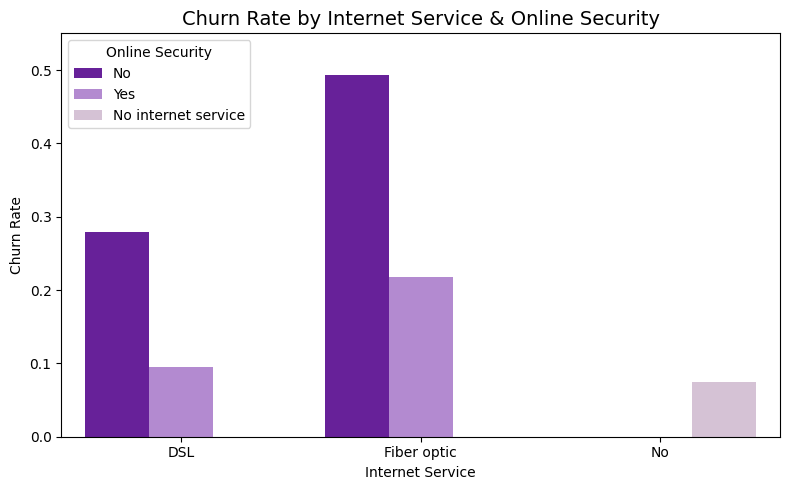

In [39]:
# Online Security VS Churn Rate
internet_churn = df.groupby(["InternetService","OnlineSecurity"])["Churn"].mean().reset_index()
plt.figure(figsize=(8,5))
sns.barplot(
    data=internet_churn,
    x="InternetService",
    y="Churn",
    hue="OnlineSecurity",
    palette=["#6A0DAD","#B57EDC","#D8BFD8"]
)
plt.title("Churn Rate by Internet Service & Online Security", fontsize=14)
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate")
plt.ylim(0,0.55)
plt.legend(title="Online Security")
plt.tight_layout()
plt.show()

In [41]:
#Common payment method used by customers
print(df["PaymentMethod"].value_counts())

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64


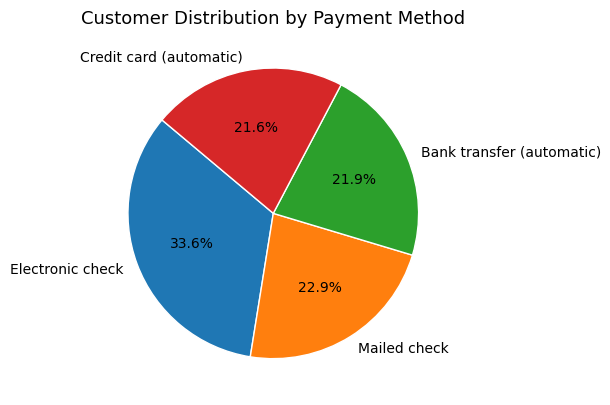

In [48]:
payment_counts = df["PaymentMethod"].value_counts()
plt.figure(figsize=(6,6))
plt.pie(
    payment_counts.values,
    labels=payment_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops={"edgecolor": "white"}
)
plt.title("Customer Distribution by Payment Method", fontsize=13)
plt.tight_layout()
plt.show()

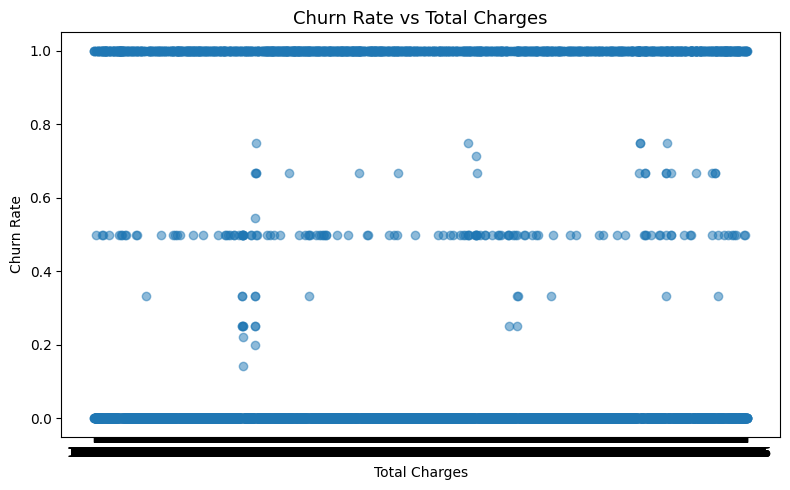

In [49]:
#Churn behaviour change with increasing total charges
data = df.groupby("TotalCharges")["Churn"].mean().reset_index()
plt.figure(figsize=(8,5))
plt.scatter(
    data["TotalCharges"],
    data["Churn"],
    alpha=0.5
)
plt.title("Churn Rate vs Total Charges", fontsize=13)
plt.xlabel("Total Charges")
plt.ylabel("Churn Rate")
plt.tight_layout()
plt.show()